# Unit08_Example_04 | 化工案例四：氣固流體化床壓力梯度與固體粒子體積分率

本 Notebook 使用 `Unit08/` 中的量測數據，示範**數值微分**在化工問題中的應用。

## 目標
- 由軸向壓力量測值，使用 `numpy.gradient()` 計算各位置壓力梯度 $dP/dz$
- 由動量平衡方程推導，利用壓力梯度計算各位置固體粒子體積分率 $\varepsilon_s$
- 比較前向差分、後向差分、中間差分三種方法的計算結果
- 計算固體粒子平均體積分率，並繪製軸向分布圖

---
### 0. 環境設定

In [29]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit08_Example_04'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit08'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit08
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_04
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_04\figs


---
### 1. 載入套件

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
})

import matplotlib
print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  matplotlib 版本: 3.10.8


---
### 2. 問題描述與實驗數據

**系統參數**

在氣固循環流體化床（CFB Riser）中，固體催化劑（FCC，粒徑 $d_p = 70\ \mu\mathrm{m}$ ，密度 $\rho_s = 1500\ \mathrm{kg/m^3}$ ）由空氣（ $\rho_g = 1.2\ \mathrm{kg/m^3}$ ）沿 $z$ 方向輸送。  
提升管高度 $H = 5.0\ \mathrm{m}$ ，沿軸向 10 個非等間距位置裝設壓力感測器。

**固體粒子體積分率推導（動量平衡簡化）**

$$
\varepsilon_s(z) = \frac{-dP/dz}{\rho_s\,g}
\quad \Rightarrow \quad
\varepsilon_s = \frac{|dP/dz|\ [\mathrm{Pa/m}]}{1500 \times 9.81\ [\mathrm{Pa/m}]}
$$

In [31]:
# ============================================================
# 系統參數設定
# ============================================================
rho_s = 1500.0   # 固體粒子密度 (kg/m³)
rho_g =    1.2   # 氣體（空氣）密度 (kg/m³)
g     =   9.81   # 重力加速度 (m/s²)

# ============================================================
# 軸向壓力量測數據（非等間距）
# ============================================================
# 軸向位置 (m)
z = np.array([0.0, 0.3, 0.7, 1.2, 1.8, 2.5, 3.2, 3.9, 4.6, 5.0])

# 錶壓量測值 (kPa)，頂端 z=5.0 m 為零壓參考點
P = np.array([5.31, 4.49, 3.67, 2.81, 2.13, 1.46, 0.97, 0.58, 0.21, 0.00])

H = z[-1] - z[0]   # 全床高度 (m)
N = len(z)          # 量測點數

# ============================================================
# 顯示原始數據
# ============================================================
print("=" * 60)
print("  氣固流體化床 — 軸向壓力量測數據")
print("=" * 60)
print(f"{'位置 z (m)':>12s}  {'量測壓力 P (kPa)':>18s}")
print("-" * 35)
for zi, Pi in zip(z, P):
    print(f"{zi:>12.1f}  {Pi:>18.2f}")
print("=" * 60)
print(f"\n系統參數:")
print(f"  固體密度  ρ_s = {rho_s:.0f} kg/m³")
print(f"  氣體密度  ρ_g = {rho_g:.1f} kg/m³")
print(f"  重力加速度 g  = {g:.2f} m/s²")
print(f"  ρ_s × g       = {rho_s*g:.1f} Pa/m")

  氣固流體化床 — 軸向壓力量測數據
    位置 z (m)        量測壓力 P (kPa)
-----------------------------------
         0.0                5.31
         0.3                4.49
         0.7                3.67
         1.2                2.81
         1.8                2.13
         2.5                1.46
         3.2                0.97
         3.9                0.58
         4.6                0.21
         5.0                0.00

系統參數:
  固體密度  ρ_s = 1500 kg/m³
  氣體密度  ρ_g = 1.2 kg/m³
  重力加速度 g  = 9.81 m/s²
  ρ_s × g       = 14715.0 Pa/m


---
### 3. 數值微分 — `numpy.gradient()`

`numpy.gradient(P, z)` 自動對非均勻間距數據計算差分導數：
- **內部點** → 加權差分公式（非均勻間距，二階精確）
- **兩端點** → 單側差分（一階精確）

計算流程：

$$
\frac{dP}{dz}\bigg|_i \xrightarrow{\div (-\rho_s g)} \varepsilon_s(z_i)
$$


In [32]:
# ============================================================
# 數值微分：使用 numpy.gradient() 計算壓力梯度
# ============================================================

# dP/dz (kPa/m) — 自動處理非均勻間距
dPdz_gradient = np.gradient(P, z)

# 固體粒子體積分率：ε_s = -dP/dz [Pa/m] / (ρ_s × g)
# 注意：P 單位為 kPa，需乘以 1000 換算為 Pa
eps_s_gradient = -dPdz_gradient * 1000.0 / (rho_s * g)

# ============================================================
# 顯示結果
# ============================================================
print("=" * 70)
print("  數值微分結果（numpy.gradient）— 壓力梯度與固體體積分率")
print("=" * 70)
print(f"{'z (m)':>8s}  {'P (kPa)':>10s}  {'dP/dz (kPa/m)':>15s}  {'ε_s (-)':>10s}")
print("-" * 50)
for i in range(N):
    print(f"{z[i]:>8.1f}  {P[i]:>10.2f}  {dPdz_gradient[i]:>15.3f}  {eps_s_gradient[i]:>10.4f}")

# 平均固體體積分率（梯形積分）
eps_s_mean = np.trapz(eps_s_gradient, z) / H
print("=" * 70)
print(f"\n  全床平均固體粒子體積分率:")
print(f"  ε̄_s = {eps_s_mean:.4f}  ({eps_s_mean*100:.2f}%)")
print(f"\n  底部 z=0.0 m: ε_s = {eps_s_gradient[0]:.4f} ({eps_s_gradient[0]*100:.1f}%)")
print(f"  頂部 z=5.0 m: ε_s = {eps_s_gradient[-1]:.4f} ({eps_s_gradient[-1]*100:.1f}%)")

  數值微分結果（numpy.gradient）— 壓力梯度與固體體積分率
   z (m)     P (kPa)    dP/dz (kPa/m)     ε_s (-)
--------------------------------------------------
     0.0        5.31           -2.733      0.1858
     0.3        4.49           -2.440      0.1658
     0.7        3.67           -1.903      0.1293
     1.2        2.81           -1.453      0.0988
     1.8        2.13           -1.052      0.0715
     2.5        1.46           -0.829      0.0563
     3.2        0.97           -0.629      0.0427
     3.9        0.58           -0.543      0.0369
     4.6        0.21           -0.526      0.0358
     5.0        0.00           -0.525      0.0357

  全床平均固體粒子體積分率:
  ε̄_s = 0.0734  (7.34%)

  底部 z=0.0 m: ε_s = 0.1858 (18.6%)
  頂部 z=5.0 m: ε_s = 0.0357 (3.6%)


---
### 4. 三種差分方法比較

手動計算**前向差分（Forward）**、**後向差分（Backward）**、**中間差分（Central）**，  
與 `numpy.gradient()` 結果對比，驗證各方法的精確度差異。

| 方法 | 精確度（截斷誤差） | 端點處理 |
|:----:|:-----------------:|:--------:|
| 前向差分 | $O(\Delta z)$ | 最後一點改用後向差分 |
| 後向差分 | $O(\Delta z)$ | 第一點改用前向差分 |
| 中間差分 | $O(\Delta z)$（非均勻間距） | 端點改用單側差分 |
| `numpy.gradient()` | $O(\Delta z^2)$（非均勻間距，加權公式） | 自動統一處理端點 |

> **關鍵差異**：本例量測位置**非等間距**，手動中間差分 $(P_{i+1}-P_{i-1})/(z_{i+1}-z_{i-1})$ 為一階精確；  
> `numpy.gradient()` 使用加權公式，非均勻間距下達到二階精確，兩者結果**並不相同**（最大差 ≈ 0.098 kPa/m）。

In [33]:
# ============================================================
# 前向差分 (Forward Difference)
# ============================================================
dPdz_fwd = np.zeros(N)
for i in range(N - 1):
    dPdz_fwd[i] = (P[i+1] - P[i]) / (z[i+1] - z[i])
# 最後一點：後向差分補齊
dPdz_fwd[-1] = (P[-1] - P[-2]) / (z[-1] - z[-2])

# ============================================================
# 後向差分 (Backward Difference)
# ============================================================
dPdz_bwd = np.zeros(N)
for i in range(1, N):
    dPdz_bwd[i] = (P[i] - P[i-1]) / (z[i] - z[i-1])
# 第一點：前向差分補齊
dPdz_bwd[0] = (P[1] - P[0]) / (z[1] - z[0])

# ============================================================
# 中間差分 (Central Difference)
# ============================================================
dPdz_cen = np.zeros(N)
for i in range(1, N - 1):
    dPdz_cen[i] = (P[i+1] - P[i-1]) / (z[i+1] - z[i-1])
# 兩端點：前向/後向差分補齊
dPdz_cen[0]  = (P[1]  - P[0])  / (z[1]  - z[0])
dPdz_cen[-1] = (P[-1] - P[-2]) / (z[-1] - z[-2])

# ============================================================
# 各方法計算固體粒子體積分率
# ============================================================
eps_fwd = -dPdz_fwd * 1000.0 / (rho_s * g)
eps_bwd = -dPdz_bwd * 1000.0 / (rho_s * g)
eps_cen = -dPdz_cen * 1000.0 / (rho_s * g)

# ============================================================
# 比較表格
# ============================================================
print("=" * 90)
print("  三種差分方法比較 — 壓力梯度 dP/dz (kPa/m) / 固體體積分率 ε_s (-)")
print("=" * 90)
header = f"{'z':>5s}  {'P':>6s}  {'fwd dPdz':>10s}  {'bwd dPdz':>10s}  {'cen dPdz':>10s}  {'grad dPdz':>11s}  {'ε_s(cen)':>9s}"
print(header)
print("-" * 80)
for i in range(N):
    print(f"{z[i]:>5.1f}  {P[i]:>6.2f}  "
          f"{dPdz_fwd[i]:>10.3f}  {dPdz_bwd[i]:>10.3f}  "
          f"{dPdz_cen[i]:>10.3f}  {dPdz_gradient[i]:>11.3f}  "
          f"{eps_cen[i]:>9.4f}")
print("=" * 90)
print("\n中間差分與 numpy.gradient() 結果比較（最大絕對差）:")
print(f"  max|Δ(dP/dz)| = {np.max(np.abs(dPdz_cen - dPdz_gradient)):.6f} kPa/m")

  三種差分方法比較 — 壓力梯度 dP/dz (kPa/m) / 固體體積分率 ε_s (-)
    z       P    fwd dPdz    bwd dPdz    cen dPdz    grad dPdz   ε_s(cen)
--------------------------------------------------------------------------------
  0.0    5.31      -2.733      -2.733      -2.733       -2.733     0.1858
  0.3    4.49      -2.050      -2.733      -2.343       -2.440     0.1592
  0.7    3.67      -1.720      -2.050      -1.867       -1.903     0.1269
  1.2    2.81      -1.133      -1.720      -1.400       -1.453     0.0951
  1.8    2.13      -0.957      -1.133      -1.038       -1.052     0.0706
  2.5    1.46      -0.700      -0.957      -0.829       -0.829     0.0563
  3.2    0.97      -0.557      -0.700      -0.629       -0.629     0.0427
  3.9    0.58      -0.529      -0.557      -0.543       -0.543     0.0369
  4.6    0.21      -0.525      -0.529      -0.527       -0.526     0.0358
  5.0    0.00      -0.525      -0.525      -0.525       -0.525     0.0357

中間差分與 numpy.gradient() 結果比較（最大絕對差）:
  max|Δ(dP/dz)| = 0

---
### 5. 圖形繪製

繪製三張圖：
1. **圖1** — 軸向壓力分布（量測數據點）
2. **圖2** — 三種差分方法所得壓力梯度 $dP/dz$ 之比較
3. **圖3** — 固體粒子體積分率 $\varepsilon_s$ 軸向分布（含平均值標線）

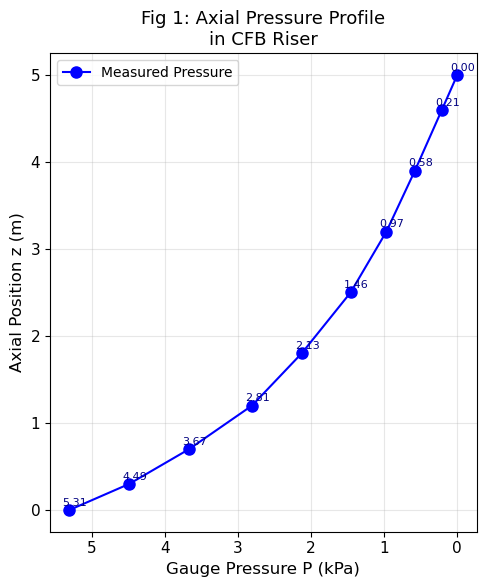

圖1 已儲存：d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_04\figs\fig1_pressure_profile.png


In [34]:
# ============================================================
# 圖1：軸向壓力分布
# ============================================================
fig1, ax1 = plt.subplots(figsize=(5, 6))

ax1.plot(P, z, 'bo-', markersize=8, linewidth=1.5, label='Measured Pressure')

ax1.set_xlabel('Gauge Pressure P (kPa)')
ax1.set_ylabel('Axial Position z (m)')
ax1.set_title('Fig 1: Axial Pressure Profile\nin CFB Riser')
ax1.legend()
ax1.invert_xaxis()   # 壓力由左（高）到右（低），直觀顯示

# 標示各量測點壓力值
for zi, Pi in zip(z, P):
    ax1.annotate(f'{Pi:.2f}', xy=(Pi, zi),
                 xytext=(-5, 3), textcoords='offset points',
                 fontsize=8, color='navy')

fig1.tight_layout()
fig1.savefig(FIG_DIR / 'fig1_pressure_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"圖1 已儲存：{FIG_DIR / 'fig1_pressure_profile.png'}")

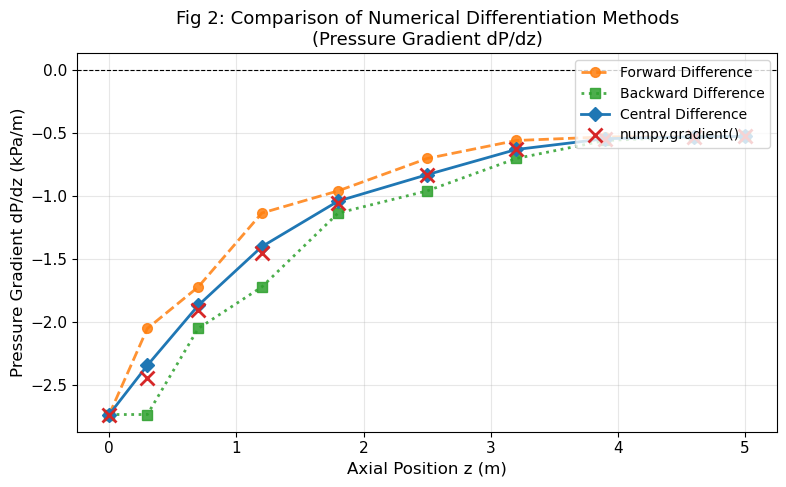

圖2 已儲存：d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_04\figs\fig2_dPdz_comparison.png


In [35]:
# ============================================================
# 圖2：三種差分方法壓力梯度比較
# ============================================================
fig2, ax2 = plt.subplots(figsize=(8, 5))

ax2.plot(z, dPdz_fwd,      'o--',  color='tab:orange', label='Forward Difference',  alpha=0.85)
ax2.plot(z, dPdz_bwd,      's:',   color='tab:green',  label='Backward Difference', alpha=0.85)
ax2.plot(z, dPdz_cen,      'D-',   color='tab:blue',   label='Central Difference',  linewidth=2.0)
ax2.plot(z, dPdz_gradient, 'x',    color='tab:red',    label='numpy.gradient()',    markersize=10,
         markeredgewidth=2)

ax2.set_xlabel('Axial Position z (m)')
ax2.set_ylabel('Pressure Gradient dP/dz (kPa/m)')
ax2.set_title('Fig 2: Comparison of Numerical Differentiation Methods\n(Pressure Gradient dP/dz)')
ax2.legend(loc='upper right')
ax2.axhline(0, color='k', linewidth=0.8, linestyle='--')

fig2.tight_layout()
fig2.savefig(FIG_DIR / 'fig2_dPdz_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"圖2 已儲存：{FIG_DIR / 'fig2_dPdz_comparison.png'}")

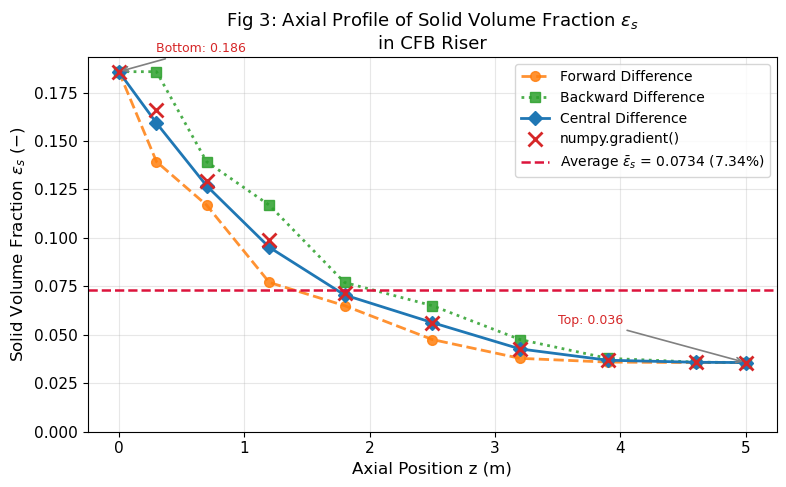

圖3 已儲存：d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_04\figs\fig3_solid_fraction.png


In [36]:
# ============================================================
# 圖3：固體粒子體積分率軸向分布
# ============================================================
fig3, ax3 = plt.subplots(figsize=(8, 5))

ax3.plot(z, eps_fwd,        'o--',  color='tab:orange', label='Forward Difference',  alpha=0.85)
ax3.plot(z, eps_bwd,        's:',   color='tab:green',  label='Backward Difference', alpha=0.85)
ax3.plot(z, eps_cen,        'D-',   color='tab:blue',   label='Central Difference',  linewidth=2.0)
ax3.plot(z, eps_s_gradient, 'x',    color='tab:red',    label='numpy.gradient()',    markersize=10, markeredgewidth=2)

# 平均值水平線
ax3.axhline(eps_s_mean, color='crimson', linestyle='--', linewidth=1.8,
            label=f'Average $\\bar{{\\varepsilon}}_s$ = {eps_s_mean:.4f} ({eps_s_mean*100:.2f}%)')

# 文字標示
ax3.annotate(f'Bottom: {eps_s_gradient[0]:.3f}',
             xy=(z[0], eps_s_gradient[0]), xytext=(0.3, eps_s_gradient[0]+0.01),
             fontsize=9, color='tab:red',
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
ax3.annotate(f'Top: {eps_s_gradient[-1]:.3f}',
             xy=(z[-1], eps_s_gradient[-1]), xytext=(3.5, eps_s_gradient[-1]+0.02),
             fontsize=9, color='tab:red',
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

ax3.set_xlabel('Axial Position z (m)')
ax3.set_ylabel(r'Solid Volume Fraction $\varepsilon_s$ (−)')
ax3.set_title(r'Fig 3: Axial Profile of Solid Volume Fraction $\varepsilon_s$' + '\nin CFB Riser')
ax3.legend(loc='upper right')
ax3.set_ylim(bottom=0)

fig3.tight_layout()
fig3.savefig(FIG_DIR / 'fig3_solid_fraction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"圖3 已儲存：{FIG_DIR / 'fig3_solid_fraction.png'}")

---
### 6. 重點整理

| 項目 | 說明 |
|:----:|:-----|
| **技術核心** | 由壓力梯度 $dP/dz < 0$ 搭配動量平衡，反推固體體積分率 $\varepsilon_s = -dP/dz \,/\, (\rho_s g)$ |
| **`numpy.gradient()`** | 自動適應非均勻間距；使用加權差分公式，達二階精確 $O(\Delta z^2)$，優於手動中間差分 |
| **三種差分比較** | 對**非均勻間距**，手動中間差分僅一階精確；`numpy.gradient()` 加權公式較精確，本例最大差 ≈ 0.098 kPa/m |
| **端點誤差** | $z=0$ 和 $z=H$ 端點僅能用一階差分，略低於內部點精確度 |
| **量綱轉換** | $P$ 單位 kPa → 乘以 1000 換算 Pa 後再除以 $\rho_s g$ （Pa/m） |
| **平均體積分率** | 使用 `numpy.trapz()` 計算梯形積分得 $\bar{\varepsilon}_s \approx 7.34\%$ |
| **物理意義** | 底部密相（ $\varepsilon_s \approx 18.6\%$ ）→ 頂部稀相（ $\varepsilon_s \approx 3.6\%$ ），CFB 提升管之典型軸向分布 |